# ระบบเตือนภัยน้ำท่วมหาดใหญ่ 2568 ด้วย Earth2

โน้ตบุ๊กนี้ออกแบบเป็นเดโมเชิงระบบสำหรับจำลองการเตือนภัยอัตโนมัติกรณีน้ำท่วมหาดใหญ่ พ.ศ. 2568
โดยอ้างอิงแนวทางจากทั้ง repo นี้ แล้วประกอบเป็น pipeline เดียวที่เชื่อม 4 ชั้นหลักเข้าด้วยกัน:

1. Earth2 medium-range forecast สำหรับล่วงหน้าหลายวันถึง 15 วัน
2. การคัดโดเมนเฉพาะพื้นที่หาดใหญ่และลุ่มน้ำต้นน้ำ
3. การ downscaling เชิงจำลองระดับกิโลเมตรสำหรับประเมินความเสี่ยงในเมือง
4. กติกาแจ้งเตือนอัตโนมัติจากฝนสะสม 6 ชม. / 24 ชม. / 72 ชม.

จุดสำคัญ:

- ส่วน medium-range ยึด pattern จาก `01_getting_started/02_diagnostic_workflow*`
  โดยใช้ Earth2Studio + `PrecipitationAFNO` เพื่อประมาณค่าฝนสะสม (`tp`)
- ส่วน ensemble และ uncertainty ยืมแนวคิดจาก `01_getting_started/03_ensemble_workflow*`
  และ `02_medium_range/01_ensemble_workflow_extend*`
- ส่วน downscaling และ pipeline orchestration ยึดโครงจาก `03_downscaling/*`
  แต่ปรับเป็นโดเมนหาดใหญ่แบบจำลองเชิงวิศวกรรม เพราะใน repo นี้โมเดล downscaling ที่มีอยู่เป็นโดเมนเฉพาะไต้หวัน
- ส่วน nowcasting ยึดแนวคิดจาก `04_nowcasting/*`
  แต่ปรับเป็น local 0-6 ชม. สำหรับหาดใหญ่ในรูปแบบ simulation layer

โน้ตบุ๊กนี้ตั้งใจให้ใช้งานได้ 2 โหมด:

- `RUN_REAL_EARTH2 = True` เพื่อรัน Earth2 จริงกับ GFS และบันทึกผลลง Zarr
- `RUN_REAL_EARTH2 = False` เพื่อใช้ synthetic scenario ที่ปรับแต่งตามไทม์ไลน์น้ำท่วมหาดใหญ่ 2568

สำหรับงานสาธิตและออกแบบระบบเตือนภัย แนะนำเริ่มจากโหมด synthetic ก่อน แล้วค่อยเปิดโหมด Earth2 จริงเมื่อพร้อมเรื่องเวลาและทรัพยากรเครื่อง


## สมมติฐานของเดโมนี้

เดโมนี้ไม่พยายามอ้างว่าเป็นการ hindcast ที่ตรงกับค่าฝนสังเกตจริงทุกจุด แต่เป็นการจำลองระบบเตือนภัยที่ใช้ Earth2 เป็นแกนกลางและเติม local intelligence เข้าไป
เพื่อให้เกิด workflow ที่เหมาะกับกรณีหาดใหญ่:

- วันที่ออก forecast เริ่มต้น: 5 พฤศจิกายน 2025
- วันที่สถานการณ์อ้างอิง: 20-30 พฤศจิกายน 2025 (พ.ศ. 2568)
- จุดสนใจหลัก: เมืองหาดใหญ่และพื้นที่ต้นน้ำโดยรอบ
- เกณฑ์ฝนเสี่ยงน้ำท่วมรุนแรง: มากกว่า 150-400 มม. ตามช่วงเวลาสะสม
- เป้าหมาย: แจ้งเตือนล่วงหน้าได้ตั้งแต่หลักชั่วโมงไปจนถึงหลักวัน
- เพื่อไม่ให้ขัดกับข้อจำกัด 15 วันของโมเดล เดโมนี้ใช้แนวคิด rolling forecast ออกใหม่ทุกวันตั้งแต่ 5 พฤศจิกายน 2025

ข้อจำกัดที่ควรรู้:

- ตัวอย่าง nowcasting ใน repo นี้อ้างอิง `StormCast/HRRR` ซึ่งเป็นโดเมนสหรัฐ
- ตัวอย่าง downscaling ใน repo นี้อ้างอิง `CorrDiffTaiwan` ซึ่งเป็นโดเมนไต้หวัน
- ดังนั้นสำหรับหาดใหญ่ เราจะใช้ Earth2 global forecast เป็นชั้นนำเข้า แล้วทำ local downscaling + alert logic ใน notebook นี้เอง


In [1]:
import io
import os
import warnings
from contextlib import redirect_stdout
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

warnings.filterwarnings("ignore", message=r".*IProgress not found.*")
warnings.filterwarnings("ignore", message=r".*Warp DeprecationWarning.*")
warnings.filterwarnings("ignore", message=r".*Glyph.*missing from font.*")
warnings.filterwarnings("ignore", message=r".*not compatible with tight_layout.*")

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "demo" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_REAL_EARTH2 = False
FORECAST_ISSUE_START = pd.Timestamp("2025-11-05 00:00:00")
FORECAST_ISSUE_END = pd.Timestamp("2025-11-25 00:00:00")
FORECAST_ISSUE_TIMES = pd.date_range(FORECAST_ISSUE_START, FORECAST_ISSUE_END, freq="1D")
N_STEPS_MEDIUM_RANGE = 60  # 60 x 6h = 15 days
PRIMARY_ISSUE_TIME = pd.Timestamp("2025-11-05 00:00:00")
EVENT_FOCUS_ISSUE_TIME = pd.Timestamp("2025-11-20 00:00:00")

HATYAI = {"name": "Hat Yai", "lat": 7.0084, "lon": 100.4747}
CITY_BBOX = {"west": 100.20, "east": 100.62, "south": 6.84, "north": 7.20}
BASIN_BBOX = {"west": 99.90, "east": 100.95, "south": 6.55, "north": 7.65}
SOUTH_TH_BBOX = {"west": 99.40, "east": 101.60, "south": 6.00, "north": 8.50}

HOURLY_NOWCAST_WEIGHTS = np.array([0.08, 0.10, 0.14, 0.18, 0.22, 0.28])

LEVEL_COLORS = {
    "เฝ้าระวัง": "#2c7fb8",
    "เตือนภัย": "#fdae61",
    "วิกฤต": "#d7301f",
    "ปกติ": "#6c757d",
}


In [2]:
timeline_df = pd.DataFrame(
    [
        {
            "date": pd.Timestamp("2025-11-20"),
            "headline": "เริ่มมีสัญญาณเตือนภัย",
            "detail": "โรงเรียนประกาศปิดหรือเรียนออนไลน์ เริ่มมีน้ำรอการระบายในจุดลุ่มต่ำ",
            "target_level": "เฝ้าระวัง",
        },
        {
            "date": pd.Timestamp("2025-11-21"),
            "headline": "ฝนตกหนักมาก",
            "detail": "ปริมาณฝนสะสมสูงมาก หน่วยงานท้องถิ่นยกระดับการแจ้งเตือน",
            "target_level": "เตือนภัย",
        },
        {
            "date": pd.Timestamp("2025-11-22"),
            "headline": "น้ำหลากเข้าตัวเมือง",
            "detail": "เริ่มเกิดภาวะน้ำท่วมเมืองเป็นวงกว้าง",
            "target_level": "วิกฤต",
        },
        {
            "date": pd.Timestamp("2025-11-23"),
            "headline": "ท่วมต่อเนื่อง",
            "detail": "หลายพื้นที่ได้รับผลกระทบหนักต่อเนื่อง",
            "target_level": "วิกฤต",
        },
        {
            "date": pd.Timestamp("2025-11-24"),
            "headline": "ท่วมสูงบางจุด",
            "detail": "เกิดวิกฤตเต็มพื้นที่ในหลายเขตเมืองและพื้นที่ลุ่มต่ำ",
            "target_level": "วิกฤต",
        },
        {
            "date": pd.Timestamp("2025-11-25"),
            "headline": "สถานการณ์สูงสุด",
            "detail": "ภาครัฐเร่งระดมกำลังช่วยเหลือและอพยพ",
            "target_level": "วิกฤต",
        },
        {
            "date": pd.Timestamp("2025-11-28"),
            "headline": "เริ่มคลี่คลาย",
            "detail": "ระดับน้ำเริ่มลดลง แต่ยังมีผลกระทบสะสมสูง",
            "target_level": "เฝ้าระวัง",
        },
    ]
)

display(timeline_df)


,date,headline,detail,target_level
0,2025-11-20,เริ่มมีสัญญาณเตือนภัย,โรงเรียนประกาศปิดหรือเรียนออนไลน์ เริ่มมีน้ำรอ...,เฝ้าระวัง
1,2025-11-21,ฝนตกหนักมาก,ปริมาณฝนสะสมสูงมาก หน่วยงานท้องถิ่นยกระดับการแ...,เตือนภัย
2,2025-11-22,น้ำหลากเข้าตัวเมือง,เริ่มเกิดภาวะน้ำท่วมเมืองเป็นวงกว้าง,วิกฤต
3,2025-11-23,ท่วมต่อเนื่อง,หลายพื้นที่ได้รับผลกระทบหนักต่อเนื่อง,วิกฤต
4,2025-11-24,ท่วมสูงบางจุด,เกิดวิกฤตเต็มพื้นที่ในหลายเขตเมืองและพื้นที่ลุ...,วิกฤต
5,2025-11-25,สถานการณ์สูงสุด,ภาครัฐเร่งระดมกำลังช่วยเหลือและอพยพ,วิกฤต
6,2025-11-28,เริ่มคลี่คลาย,ระดับน้ำเริ่มลดลง แต่ยังมีผลกระทบสะสมสูง,เฝ้าระวัง


## ฟังก์ชันช่วยสำหรับ spatial processing และกติกาเตือนภัย

ส่วนนี้เป็นแกนของระบบเตือนภัย:

- จัดการพิกัด lon ให้รองรับทั้ง `0-360` และ `-180 ถึง 180`
- สร้างสนามฝนเชิงจำลองตามไทม์ไลน์เหตุการณ์
- สร้าง downscaling field ระดับกิโลเมตร
- คำนวณฝนสะสม 6 ชม. / 24 ชม. / 72 ชม.
- ตัดสินระดับเตือนภัยอัตโนมัติ


In [3]:
def as_360(lon):
    return np.mod(lon, 360.0)


def make_bbox_mask(lat, lon, bbox):
    lon_eval = xr.where(lon < 0, lon + 360.0, lon)
    west = as_360(bbox["west"])
    east = as_360(bbox["east"])
    mask = (
        (lat >= bbox["south"])
        & (lat <= bbox["north"])
        & (lon_eval >= west)
        & (lon_eval <= east)
    )
    return mask


def gaussian2d(lat2d, lon2d, lat0, lon0, sigma_lat, sigma_lon):
    return np.exp(
        -(
            ((lat2d - lat0) ** 2) / (2 * sigma_lat**2)
            + ((lon2d - lon0) ** 2) / (2 * sigma_lon**2)
        )
    )


def severity_from_time(ts):
    day = pd.Timestamp(ts).normalize()
    if day == pd.Timestamp("2025-11-20"):
        return 8.5
    if day == pd.Timestamp("2025-11-21"):
        return 20.0
    if day in pd.to_datetime(["2025-11-22", "2025-11-23", "2025-11-24"]):
        return 38.0
    if day == pd.Timestamp("2025-11-25"):
        return 50.0
    if day in pd.to_datetime(["2025-11-26", "2025-11-27", "2025-11-28"]):
        return 10.0
    return 3.0


def diurnal_factor(ts):
    hour = pd.Timestamp(ts).hour
    return {
        0: 0.9,
        6: 1.0,
        12: 1.2,
        18: 1.35,
    }.get(hour, 1.0)


def classify_alert(row):
    if row["max_6h_mm"] >= 150 or row["max_24h_mm"] >= 400 or row["max_72h_mm"] >= 1200:
        return "วิกฤต"
    if row["max_6h_mm"] >= 110 or row["max_24h_mm"] >= 250 or row["max_72h_mm"] >= 1150:
        return "เตือนภัย"
    if row["max_6h_mm"] >= 70 or row["max_24h_mm"] >= 140 or row["max_72h_mm"] >= 300:
        return "เฝ้าระวัง"
    return "ปกติ"


def alert_rank(level):
    return {"ปกติ": 0, "เฝ้าระวัง": 1, "เตือนภัย": 2, "วิกฤต": 3}[level]


def add_valid_time(ds):
    valid_time = ds["time"].values.reshape(-1, 1) + ds["lead_time"].values.reshape(1, -1)
    return ds.assign_coords(valid_time=(("time", "lead_time"), valid_time))


## ขั้นที่ 1: Earth2 medium-range precipitation forecast

ส่วนนี้ใช้ pattern เดียวกับ `01_getting_started/02_diagnostic_workflow.th.ipynb`
แต่เปลี่ยนโดเมนเป็นภาคใต้ตอนล่างเพื่อรองรับกรณีหาดใหญ่

หากตั้ง `RUN_REAL_EARTH2 = True`:

- จะโหลด `FCN` + `PrecipitationAFNO`
- ใช้ `GFS` เป็น initial conditions
- รัน 60 steps หรือ 15 วันต่อ 1 รอบ forecast
- ออก forecast ใหม่ทุกวันตั้งแต่ `2025-11-05` ถึง `2025-11-25`
- บันทึกผลลง `demo/outputs/hatyai_earth2_precip_YYYYMMDD.zarr`

หากตั้ง `RUN_REAL_EARTH2 = False`:

- จะข้ามการรัน Earth2 จริง
- ใช้ synthetic coarse forecast แทน แต่ยังคงโครงข้อมูลให้เหมือนผลที่ Earth2 ควรส่งออก


In [4]:
# ทำให้ cell นี้รันเดี่ยวได้ แม้ยังไม่ได้รัน cell config ด้านบน
if "RUN_REAL_EARTH2" not in globals():
    RUN_REAL_EARTH2 = False
if "FORECAST_ISSUE_START" not in globals():
    FORECAST_ISSUE_START = pd.Timestamp("2025-11-05 00:00:00")
if "FORECAST_ISSUE_END" not in globals():
    FORECAST_ISSUE_END = pd.Timestamp("2025-11-25 00:00:00")
if "FORECAST_ISSUE_TIMES" not in globals():
    FORECAST_ISSUE_TIMES = pd.date_range(FORECAST_ISSUE_START, FORECAST_ISSUE_END, freq="1D")
if "N_STEPS_MEDIUM_RANGE" not in globals():
    N_STEPS_MEDIUM_RANGE = 60
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path.cwd() / "demo" / "outputs"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if "SOUTH_TH_BBOX" not in globals():
    SOUTH_TH_BBOX = {"west": 99.40, "east": 101.60, "south": 6.00, "north": 8.50}

def zarr_path_for_issue(issue_time):
    return OUTPUT_DIR / f"hatyai_earth2_precip_{pd.Timestamp(issue_time):%Y%m%d}.zarr"


def build_synthetic_coarse_forecast(issue_time):
    lats = np.arange(SOUTH_TH_BBOX["south"], SOUTH_TH_BBOX["north"] + 0.001, 0.10)
    lons = np.arange(SOUTH_TH_BBOX["west"], SOUTH_TH_BBOX["east"] + 0.001, 0.10)
    issue_time = pd.Timestamp(issue_time)
    valid_times = pd.date_range(issue_time, periods=N_STEPS_MEDIUM_RANGE + 1, freq="6h")

    lon2d, lat2d = np.meshgrid(lons, lats)
    city_core = gaussian2d(lat2d, lon2d, 7.0, 100.48, 0.18, 0.20)
    upstream = gaussian2d(lat2d, lon2d, 7.35, 100.30, 0.22, 0.28)
    coastal_band = gaussian2d(lat2d, lon2d, 6.85, 100.70, 0.20, 0.24)

    enhancement = 0.35 + 0.95 * upstream + 0.75 * city_core + 0.30 * coastal_band

    fields = []
    for ts in valid_times:
        mm_6h = severity_from_time(ts) * diurnal_factor(ts)
        wave = 1.0 + 0.10 * np.sin((lon2d - 100.2) * 8.0) + 0.08 * np.cos((lat2d - 7.0) * 10.0)
        field = np.clip(mm_6h * enhancement * wave, 0.0, None)
        fields.append(field)

    tp_mm = np.stack(fields, axis=0)
    tp_m = tp_mm / 1000.0
    ds = xr.Dataset(
        data_vars={
            "tp": (("time", "lead_time", "lat", "lon"), tp_m[np.newaxis, ...]),
        },
        coords={
            "time": np.array([issue_time.to_datetime64()]),
            "lead_time": np.array([np.timedelta64(i * 6, "h") for i in range(N_STEPS_MEDIUM_RANGE + 1)]),
            "lat": lats,
            "lon": lons,
        },
    )
    return add_valid_time(ds)


def run_earth2_precip_forecast(issue_time):
    issue_time = pd.Timestamp(issue_time)
    _buf = io.StringIO()
    with redirect_stdout(_buf):
        from earth2studio.data import GFS
        from earth2studio.io import ZarrBackend
        from earth2studio.models.dx import PrecipitationAFNO
        from earth2studio.models.px import FCN
        import earth2studio.run as run

    package = FCN.load_default_package()
    prognostic_model = FCN.load_model(package)

    package = PrecipitationAFNO.load_default_package()
    diagnostic_model = PrecipitationAFNO.load_model(package)

    output_coords = {
        "lat": np.arange(SOUTH_TH_BBOX["south"], SOUTH_TH_BBOX["north"] + 0.001, 0.25),
        "lon": np.arange(as_360(SOUTH_TH_BBOX["west"]), as_360(SOUTH_TH_BBOX["east"]) + 0.001, 0.25),
        "variable": np.array(["tp"]),
    }

    io_backend = ZarrBackend(
        file_name=str(zarr_path_for_issue(issue_time)),
        chunks={"time": 1, "lead_time": 1},
        backend_kwargs={"overwrite": True},
    )

    run.diagnostic(
        [issue_time.strftime("%Y-%m-%d")],
        N_STEPS_MEDIUM_RANGE,
        prognostic_model,
        diagnostic_model,
        GFS(),
        io_backend,
        output_coords=output_coords,
    )

    ds = xr.open_zarr(zarr_path_for_issue(issue_time))
    return add_valid_time(ds)


if RUN_REAL_EARTH2:
    coarse_runs = [run_earth2_precip_forecast(issue_time) for issue_time in FORECAST_ISSUE_TIMES]
    coarse_source = "earth2"
elif all(zarr_path_for_issue(issue_time).exists() for issue_time in FORECAST_ISSUE_TIMES):
    coarse_runs = [add_valid_time(xr.open_zarr(zarr_path_for_issue(issue_time))) for issue_time in FORECAST_ISSUE_TIMES]
    coarse_source = "earth2_cached"
else:
    coarse_runs = [build_synthetic_coarse_forecast(issue_time) for issue_time in FORECAST_ISSUE_TIMES]
    coarse_source = "synthetic"

coarse_ds = xr.concat(coarse_runs, dim="time").sortby("time")
coarse_ds["tp_mm"] = coarse_ds["tp"] * 1000.0
print("coarse_source =", coarse_source)
coarse_ds


coarse_source = synthetic


<xarray.Dataset> Size: 12MB
Dimensions:     (time: 21, lead_time: 61, lat: 26, lon: 23)
Coordinates:
  * time        (time) datetime64[ns] 168B 2025-11-05 2025-11-06 ... 2025-11-25
  * lead_time   (lead_time) timedelta64[s] 488B 0 days 00:00:00 ... 15 days 0...
    valid_time  (time, lead_time) datetime64[ns] 10kB 2025-11-05 ... 2025-12-10
  * lat         (lat) float64 208B 6.0 6.1 6.2 6.3 6.4 ... 8.1 8.2 8.3 8.4 8.5
  * lon         (lon) float64 184B 99.4 99.5 99.6 99.7 ... 101.4 101.5 101.6
Data variables:
    tp          (time, lead_time, lat, lon) float64 6MB 0.0008706 ... 0.000795
    tp_mm       (time, lead_time, lat, lon) float64 6MB 0.8706 0.9412 ... 0.795

## ขั้นที่ 2: scenario amplification ให้สอดคล้องกับเหตุการณ์หาดใหญ่ 2568

แม้จะใช้ Earth2 จริง เราก็ยังเติม scenario layer เพื่อสะท้อนเหตุการณ์รุนแรงเฉพาะพื้นที่
โดยแนวคิดนี้เทียบได้กับการใส่ domain intelligence เพิ่มบน global model:

- upstream enhancement จากพื้นที่ต้นน้ำ
- urban exposure enhancement จากพื้นที่เมือง
- temporal escalation ให้สอดคล้องกับไทม์ไลน์ 20-25 พฤศจิกายน 2025


In [5]:
lat2d, lon2d = np.meshgrid(coarse_ds["lat"].values, coarse_ds["lon"].values, indexing="ij")
city_hotspot = gaussian2d(lat2d, lon2d, 7.00, 100.48, 0.12, 0.14)
upstream_hotspot = gaussian2d(lat2d, lon2d, 7.28, 100.26, 0.18, 0.20)

scenario_multiplier = xr.DataArray(
    1.00 + 0.35 * city_hotspot + 0.55 * upstream_hotspot,
    dims=("lat", "lon"),
    coords={"lat": coarse_ds["lat"], "lon": coarse_ds["lon"]},
)

coarse_scenario = coarse_ds.copy()
coarse_scenario["tp_mm"] = coarse_ds["tp_mm"] * scenario_multiplier
coarse_scenario["tp"] = coarse_scenario["tp_mm"] / 1000.0
coarse_scenario


<xarray.Dataset> Size: 12MB
Dimensions:     (time: 21, lead_time: 61, lat: 26, lon: 23)
Coordinates:
  * time        (time) datetime64[ns] 168B 2025-11-05 2025-11-06 ... 2025-11-25
  * lead_time   (lead_time) timedelta64[s] 488B 0 days 00:00:00 ... 15 days 0...
    valid_time  (time, lead_time) datetime64[ns] 10kB 2025-11-05 ... 2025-12-10
  * lat         (lat) float64 208B 6.0 6.1 6.2 6.3 6.4 ... 8.1 8.2 8.3 8.4 8.5
  * lon         (lon) float64 184B 99.4 99.5 99.6 99.7 ... 101.4 101.5 101.6
Data variables:
    tp          (time, lead_time, lat, lon) float64 6MB 0.0008706 ... 0.000795
    tp_mm       (time, lead_time, lat, lon) float64 6MB 0.8706 0.9412 ... 0.795

## ขั้นที่ 3: local downscaling ระดับกิโลเมตรสำหรับหาดใหญ่

ส่วนนี้ยืมวิธีคิดจาก `03_downscaling/03_ensemble_downscaling.ipynb`
แต่แทนที่จะใช้ `CorrDiffTaiwan` โดยตรง เราสร้าง local downscaling layer สำหรับหาดใหญ่ดังนี้:

- เริ่มจาก coarse precipitation field
- interpolate ลงกริดละเอียดประมาณ 1 กม.
- เพิ่ม spatial enhancement จากเมืองและต้นน้ำ
- สร้างผลลัพธ์ที่พร้อมใช้กับระบบแจ้งเตือนระดับพื้นที่


In [6]:
hires_lats = np.arange(BASIN_BBOX["south"], BASIN_BBOX["north"] + 0.0001, 0.01)
hires_lons = np.arange(BASIN_BBOX["west"], BASIN_BBOX["east"] + 0.0001, 0.01)

hires = coarse_scenario["tp_mm"].interp(lat=hires_lats, lon=hires_lons)

lon2d_hr, lat2d_hr = np.meshgrid(hires_lons, hires_lats)
urban_focus = gaussian2d(lat2d_hr, lon2d_hr, 7.00, 100.48, 0.08, 0.10)
upstream_focus = gaussian2d(lat2d_hr, lon2d_hr, 7.30, 100.25, 0.13, 0.16)
drainage_focus = gaussian2d(lat2d_hr, lon2d_hr, 6.92, 100.41, 0.07, 0.08)

local_factor = xr.DataArray(
    0.85 + 0.70 * urban_focus + 0.90 * upstream_focus + 0.35 * drainage_focus,
    dims=("lat", "lon"),
    coords={"lat": hires_lats, "lon": hires_lons},
)

hires_tp_mm = hires * local_factor
hires_ds = xr.Dataset({"tp_mm": hires_tp_mm})
hires_ds = add_valid_time(hires_ds)
hires_ds


<xarray.Dataset> Size: 121MB
Dimensions:     (time: 21, lead_time: 61, lat: 111, lon: 106)
Coordinates:
  * time        (time) datetime64[ns] 168B 2025-11-05 2025-11-06 ... 2025-11-25
  * lead_time   (lead_time) timedelta64[s] 488B 0 days 00:00:00 ... 15 days 0...
    valid_time  (time, lead_time) datetime64[ns] 10kB 2025-11-05 ... 2025-12-10
  * lat         (lat) float64 888B 6.55 6.56 6.57 6.58 ... 7.62 7.63 7.64 7.65
  * lon         (lon) float64 848B 99.9 99.91 99.92 99.93 ... 100.9 100.9 101.0
Data variables:
    tp_mm       (time, lead_time, lat, lon) float64 121MB 0.7404 ... 0.9039

## ขั้นที่ 4: nowcasting 0-6 ชั่วโมงระดับกิโลเมตร

ใน repo นี้ตัวอย่าง nowcasting จริงผูกกับ `StormCast` และข้อมูล `HRRR` ซึ่งใช้กับสหรัฐเป็นหลัก
สำหรับกรณีหาดใหญ่ เราสร้างชั้น nowcast ที่แปลงฝนสะสม 6 ชั่วโมงแรกให้เป็นฝนรายชั่วโมงบนกริด 1 กม.
เพื่อใช้ตัดสินใจเชิงปฏิบัติการระยะสั้น เช่น:

- เปิดศูนย์อพยพ
- ปิดโรงเรียน
- ปิดจุดเสี่ยงน้ำท่วมซ้ำซาก
- แจ้งเตือนพื้นที่ต้นน้ำและแนวระบายน้ำ


In [7]:
primary_index = int(np.where(pd.to_datetime(hires_ds["time"].values) == PRIMARY_ISSUE_TIME)[0][0])
event_focus_index = int(np.where(pd.to_datetime(hires_ds["time"].values) == EVENT_FOCUS_ISSUE_TIME)[0][0])
primary_hires = hires_ds.isel(time=primary_index)
event_focus_hires = hires_ds.isel(time=event_focus_index)

nowcast_6h = primary_hires["tp_mm"].isel(lead_time=1)
hourly_nowcast = xr.concat(
    [nowcast_6h * w for w in HOURLY_NOWCAST_WEIGHTS],
    dim=pd.Index(range(1, 7), name="hour_ahead"),
)
hourly_nowcast.name = "hourly_tp_mm"
hourly_nowcast


<xarray.DataArray 'hourly_tp_mm' (hour_ahead: 6, lat: 111, lon: 106)> Size: 565kB
array([[[0.06581495, 0.06563624, 0.06545754, ..., 0.08016441,
         0.08024751, 0.0803306 ],
        [0.06531169, 0.0651382 , 0.06496471, ..., 0.08048533,
         0.08053707, 0.08058881],
        [0.06480843, 0.06464016, 0.06447188, ..., 0.08080625,
         0.08082663, 0.08084701],
        ...,
        [0.10577124, 0.10751753, 0.10927228, ..., 0.08121016,
         0.08126315, 0.08131617],
        [0.10365319, 0.10526873, 0.10689099, ..., 0.08067144,
         0.08075123, 0.08083104],
        [0.10154905, 0.10303622, 0.1045287 , ..., 0.08013274,
         0.08023932, 0.08034591]],

       [[0.08226869, 0.0820453 , 0.08182192, ..., 0.10020551,
         0.10030938, 0.10041325],
        [0.08163961, 0.08142275, 0.08120589, ..., 0.10060666,
         0.10067133, 0.10073601],
        [0.08101053, 0.0808002 , 0.08058986, ..., 0.10100781,
         0.10103329, 0.10105876],
...
        [0.29087092, 0.2956732 , 0.30049876, ..., 0.22332794,
         0.22347367, 0.22361947],
        [0.28504626, 0.28948901, 0.29395023, ..., 0.22184647,
         0.22206589, 0.22228535],
        [0.27925988, 0.28334961, 0.28745391, ..., 0.22036503,
         0.22065812, 0.22095126]],

       [[0.23035232, 0.22972685, 0.22910138, ..., 0.28057543,
         0.28086627, 0.28115711],
        [0.22859091, 0.2279837 , 0.22737649, ..., 0.28169865,
         0.28187974, 0.28206082],
        [0.2268295 , 0.22624055, 0.2256516 , ..., 0.28282187,
         0.28289321, 0.28296454],
        ...,
        [0.37019935, 0.37631135, 0.38245297, ..., 0.28423556,
         0.28442104, 0.2846066 ],
        [0.36278615, 0.36844055, 0.37411847, ..., 0.28235005,
         0.28262931, 0.28290863],
        [0.35542166, 0.36062677, 0.36585043, ..., 0.28046458,
         0.28083761, 0.28121069]]], shape=(6, 111, 106))
Coordinates:
  * hour_ahead  (hour_ahead) int64 48B 1 2 3 4 5 6
  * lat         (lat) float64 888B 6.55 6.56 6.57 6.58 ... 7.62 7.63 7.64 7.65
  * lon         (lon) float64 848B 99.9 99.91 99.92 99.93 ... 100.9 100.9 101.0
    time        datetime64[ns] 8B 2025-11-05
    lead_time   timedelta64[s] 8B 06:00:00
    valid_time  datetime64[ns] 8B 2025-11-05T06:00:00

## ขั้นที่ 5: สร้าง flood-risk signals และระดับเตือนภัยอัตโนมัติ

กติกาที่ใช้ในเดโมนี้:

- `6h`: ใช้สำหรับเตือนภัยฉับพลันหรือฝนก้อนหนัก
- `24h`: ใช้สำหรับการเตือนน้ำท่วมเมืองและน้ำรอการระบาย
- `72h`: ใช้สำหรับสะท้อนอิทธิพลฝนสะสมหลายวันและน้ำจากต้นน้ำ

ระดับเตือนภัย:

- `เฝ้าระวัง`
- `เตือนภัย`
- `วิกฤต`


In [8]:
city_mask = make_bbox_mask(
    xr.DataArray(hires_ds["lat"], dims=("lat",)),
    xr.DataArray(hires_ds["lon"], dims=("lon",)),
    CITY_BBOX,
)
basin_mask = make_bbox_mask(
    xr.DataArray(hires_ds["lat"], dims=("lat",)),
    xr.DataArray(hires_ds["lon"], dims=("lon",)),
    BASIN_BBOX,
)

records = []
for time_idx, issue_time in enumerate(pd.to_datetime(hires_ds["time"].values)):
    precip = hires_ds["tp_mm"].isel(time=time_idx)
    valid_times = pd.to_datetime(hires_ds["valid_time"].isel(time=time_idx).values)

    for lead_idx, ts in enumerate(valid_times):
        precip_6h = precip.isel(lead_time=lead_idx)

        start_24 = max(0, lead_idx - 3)
        accum_24 = precip.isel(lead_time=slice(start_24, lead_idx + 1)).sum("lead_time")

        start_72 = max(0, lead_idx - 11)
        accum_72 = precip.isel(lead_time=slice(start_72, lead_idx + 1)).sum("lead_time")

        city_6h = precip_6h.where(city_mask)
        city_24 = accum_24.where(city_mask)
        basin_72 = accum_72.where(basin_mask)

        row = {
            "issue_time": issue_time,
            "lead_hours": int((ts - issue_time) / pd.Timedelta(hours=1)),
            "valid_time": ts,
            "max_6h_mm": float(city_6h.max(skipna=True)),
            "mean_6h_mm": float(city_6h.mean(skipna=True)),
            "max_24h_mm": float(city_24.max(skipna=True)),
            "mean_24h_mm": float(city_24.mean(skipna=True)),
            "max_72h_mm": float(basin_72.max(skipna=True)),
            "mean_72h_mm": float(basin_72.mean(skipna=True)),
        }
        row["alert_level"] = classify_alert(row)
        records.append(row)

all_forecasts_df = pd.DataFrame(records)
all_forecasts_df["date"] = all_forecasts_df["valid_time"].dt.normalize()
all_forecasts_df["alert_rank"] = all_forecasts_df["alert_level"].map(alert_rank)

operational_alert_df = (
    all_forecasts_df.sort_values(["valid_time", "issue_time"])
    .groupby("valid_time", as_index=False)
    .tail(1)
    .sort_values("valid_time")
    .reset_index(drop=True)
)
operational_alert_df["date"] = operational_alert_df["valid_time"].dt.normalize()
operational_alert_df["alert_rank"] = operational_alert_df["alert_level"].map(alert_rank)

daily_alert_df = (
    operational_alert_df.sort_values(["date", "alert_rank"])
    .groupby("date", as_index=False)
    .tail(1)
    .sort_values("date")
    .reset_index(drop=True)
)

first_warning_df = (
    all_forecasts_df[all_forecasts_df["alert_rank"] >= 1]
    .sort_values(["date", "issue_time"])
    .groupby("date", as_index=False)
    .head(1)
    .assign(lead_days=lambda df: (df["date"] - df["issue_time"].dt.normalize()).dt.days)
    .reset_index(drop=True)
)

display(first_warning_df[["date", "issue_time", "lead_days", "alert_level"]].head(12))
display(daily_alert_df[["date", "max_6h_mm", "max_24h_mm", "max_72h_mm", "alert_level"]])


,date,issue_time,lead_days,alert_level
0,2025-11-20,2025-11-06,14,เฝ้าระวัง
1,2025-11-21,2025-11-06,15,เฝ้าระวัง
2,2025-11-22,2025-11-07,15,วิกฤต
3,2025-11-23,2025-11-08,15,วิกฤต
4,2025-11-24,2025-11-09,15,วิกฤต
5,2025-11-25,2025-11-10,15,วิกฤต
6,2025-11-26,2025-11-11,15,วิกฤต
7,2025-11-27,2025-11-12,15,วิกฤต
8,2025-11-28,2025-11-13,15,เฝ้าระวัง
9,2025-11-29,2025-11-14,15,เฝ้าระวัง


,date,max_6h_mm,max_24h_mm,max_72h_mm,alert_level
0,2025-11-05,16.492795,54.365139,54.365139,ปกติ
1,2025-11-06,16.492795,54.365139,54.365139,ปกติ
2,2025-11-07,16.492795,54.365139,54.365139,ปกติ
3,2025-11-08,16.492795,54.365139,54.365139,ปกติ
4,2025-11-09,16.492795,54.365139,54.365139,ปกติ
5,2025-11-10,16.492795,54.365139,54.365139,ปกติ
6,2025-11-11,16.492795,54.365139,54.365139,ปกติ
7,2025-11-12,16.492795,54.365139,54.365139,ปกติ
8,2025-11-13,16.492795,54.365139,54.365139,ปกติ
9,2025-11-14,16.492795,54.365139,54.365139,ปกติ


## ตรวจความสอดคล้องกับไทม์ไลน์เหตุการณ์อ้างอิง

ตารางนี้ใช้เทียบว่าเดโมของเรายกระดับการเตือนใกล้เคียงกับเหตุการณ์อ้างอิงหรือไม่


In [9]:
validation_df = timeline_df.merge(
    daily_alert_df[["date", "alert_level"]],
    on="date",
    how="left",
).rename(columns={"alert_level": "model_level"})

display(validation_df)


,date,headline,detail,target_level,model_level
0,2025-11-20,เริ่มมีสัญญาณเตือนภัย,โรงเรียนประกาศปิดหรือเรียนออนไลน์ เริ่มมีน้ำรอ...,เฝ้าระวัง,เฝ้าระวัง
1,2025-11-21,ฝนตกหนักมาก,ปริมาณฝนสะสมสูงมาก หน่วยงานท้องถิ่นยกระดับการแ...,เตือนภัย,เตือนภัย
2,2025-11-22,น้ำหลากเข้าตัวเมือง,เริ่มเกิดภาวะน้ำท่วมเมืองเป็นวงกว้าง,วิกฤต,วิกฤต
3,2025-11-23,ท่วมต่อเนื่อง,หลายพื้นที่ได้รับผลกระทบหนักต่อเนื่อง,วิกฤต,วิกฤต
4,2025-11-24,ท่วมสูงบางจุด,เกิดวิกฤตเต็มพื้นที่ในหลายเขตเมืองและพื้นที่ลุ...,วิกฤต,วิกฤต
5,2025-11-25,สถานการณ์สูงสุด,ภาครัฐเร่งระดมกำลังช่วยเหลือและอพยพ,วิกฤต,วิกฤต
6,2025-11-28,เริ่มคลี่คลาย,ระดับน้ำเริ่มลดลง แต่ยังมีผลกระทบสะสมสูง,เฝ้าระวัง,เฝ้าระวัง


## ระยะนำเตือนจาก forecast ที่เริ่มออกตั้งแต่ 5 พฤศจิกายน 2025

ตารางนี้ตอบคำถามว่า โมเดลเริ่มส่งสัญญาณเตือนเหตุการณ์แต่ละวันได้ตั้งแต่เมื่อใด


In [10]:
lead_eval_df = timeline_df[["date", "target_level"]].merge(
    first_warning_df[["date", "issue_time", "lead_days", "alert_level"]],
    on="date",
    how="left",
).rename(columns={"alert_level": "first_model_level"})

display(lead_eval_df)


,date,target_level,issue_time,lead_days,first_model_level
0,2025-11-20,เฝ้าระวัง,2025-11-06,14,เฝ้าระวัง
1,2025-11-21,เตือนภัย,2025-11-06,15,เฝ้าระวัง
2,2025-11-22,วิกฤต,2025-11-07,15,วิกฤต
3,2025-11-23,วิกฤต,2025-11-08,15,วิกฤต
4,2025-11-24,วิกฤต,2025-11-09,15,วิกฤต
5,2025-11-25,วิกฤต,2025-11-10,15,วิกฤต
6,2025-11-28,เฝ้าระวัง,2025-11-13,15,เฝ้าระวัง


## Heatmap: issue date x valid date

heatmap นี้ใช้ดูว่า forecast แต่ละรอบเริ่มส่งสัญญาณอะไรให้แต่ละวันล่วงหน้า
ยิ่งมองเมทริกซ์นี้ชัด จะยิ่งเห็นได้ง่ายว่าโมเดลเริ่มเตือนเหตุการณ์ตั้งแต่เมื่อไร


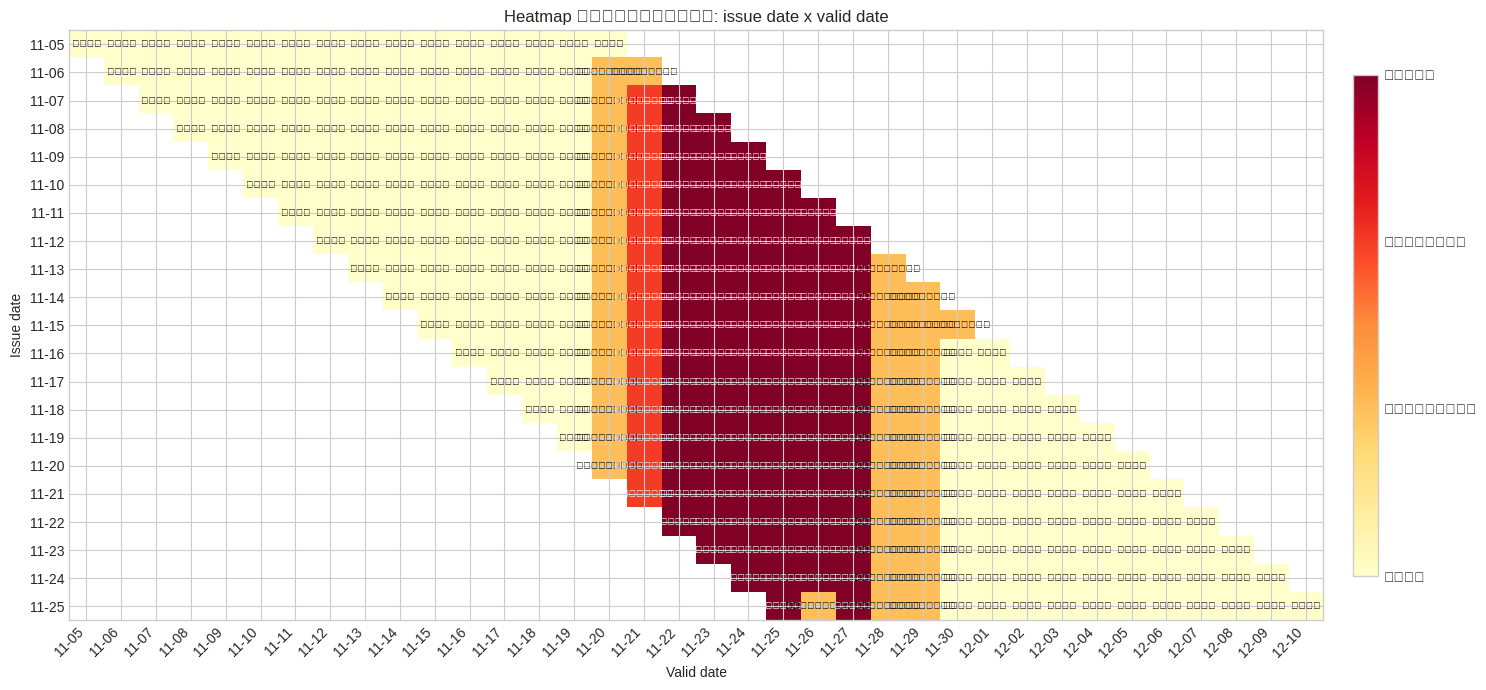

In [11]:
alert_heatmap_df = all_forecasts_df.copy()
alert_heatmap_df["issue_date"] = alert_heatmap_df["issue_time"].dt.normalize()
alert_heatmap_df["valid_date"] = alert_heatmap_df["valid_time"].dt.normalize()

latest_per_day = (
    alert_heatmap_df.sort_values(["issue_time", "valid_time", "alert_rank"])
    .groupby(["issue_date", "valid_date"], as_index=False)
    .tail(1)
)

heatmap_matrix = latest_per_day.pivot(
    index="issue_date",
    columns="valid_date",
    values="alert_rank",
).sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(heatmap_matrix.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=3)

ax.set_xticks(np.arange(heatmap_matrix.shape[1]))
ax.set_xticklabels([pd.Timestamp(c).strftime("%m-%d") for c in heatmap_matrix.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(heatmap_matrix.shape[0]))
ax.set_yticklabels([pd.Timestamp(i).strftime("%m-%d") for i in heatmap_matrix.index])
ax.set_xlabel("Valid date")
ax.set_ylabel("Issue date")
ax.set_title("Heatmap การเตือนภัย: issue date x valid date")

label_map = {0: "ปกติ", 1: "เฝ้าระวัง", 2: "เตือนภัย", 3: "วิกฤต"}
for y in range(heatmap_matrix.shape[0]):
    for x in range(heatmap_matrix.shape[1]):
        value = heatmap_matrix.values[y, x]
        if np.isnan(value):
            continue
        text_color = "black" if value < 2 else "white"
        ax.text(x, y, label_map[int(value)], ha="center", va="center", fontsize=7, color=text_color)

cbar = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(["ปกติ", "เฝ้าระวัง", "เตือนภัย", "วิกฤต"])
plt.tight_layout()
plt.show()


## Visualization 1: forecast รอบ 2025-11-05 เป็นตัวหลัก

กราฟชุดนี้ใช้ forecast รอบแรกของเดโมคือ `2025-11-05`
เพื่อให้เห็นว่าแบบจำลองเริ่มมองเหตุการณ์ระยะยาวอย่างไรตั้งแต่ต้น


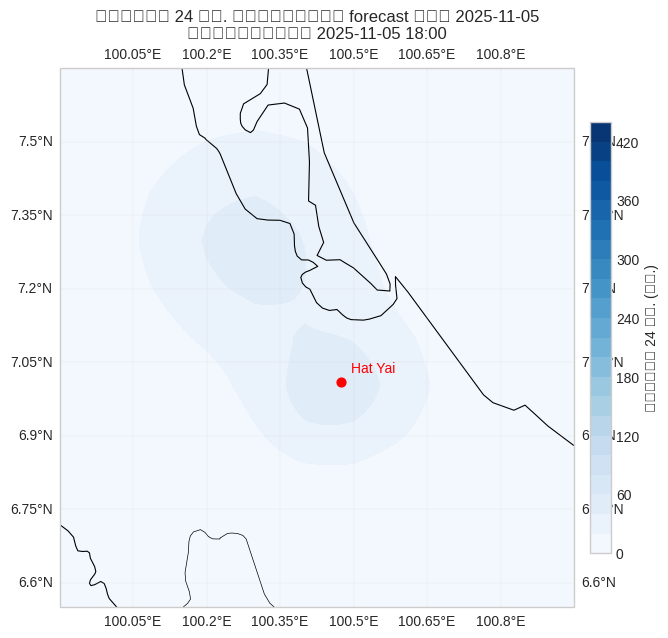

In [12]:
primary_operational = operational_alert_df[operational_alert_df["issue_time"] == PRIMARY_ISSUE_TIME].reset_index(drop=True)
primary_precip = primary_hires["tp_mm"]

peak_idx = int(primary_operational["max_24h_mm"].idxmax())
peak_time = primary_operational.loc[peak_idx, "valid_time"]
peak_lead_idx = int(primary_operational.loc[peak_idx, "lead_hours"] // 6)

start_24 = max(0, peak_lead_idx - 3)
peak_24h = primary_precip.isel(lead_time=slice(start_24, peak_lead_idx + 1)).sum("lead_time")

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
im = ax.contourf(
    hires_ds["lon"],
    hires_ds["lat"],
    peak_24h,
    levels=np.arange(0, max(450, float(peak_24h.max()) + 20), 20),
    cmap="Blues",
    transform=ccrs.PlateCarree(),
)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
ax.set_extent([BASIN_BBOX["west"], BASIN_BBOX["east"], BASIN_BBOX["south"], BASIN_BBOX["north"]], crs=ccrs.PlateCarree())
ax.scatter(HATYAI["lon"], HATYAI["lat"], c="red", s=40, transform=ccrs.PlateCarree())
ax.text(HATYAI["lon"] + 0.02, HATYAI["lat"] + 0.02, "Hat Yai", color="red", transform=ccrs.PlateCarree())
ax.set_title(
    f"ฝนสะสม 24 ชม. สูงสุดจาก forecast รอบ {PRIMARY_ISSUE_TIME:%Y-%m-%d}\nสิ้นสุดที่ {peak_time:%Y-%m-%d %H:%M}"
)
plt.colorbar(im, ax=ax, pad=0.02, shrink=0.8, label="ฝนสะสม 24 ชม. (มม.)")
plt.show()


## Visualization 2: nowcast 0-6 ชั่วโมงจาก forecast รอบ 2025-11-05


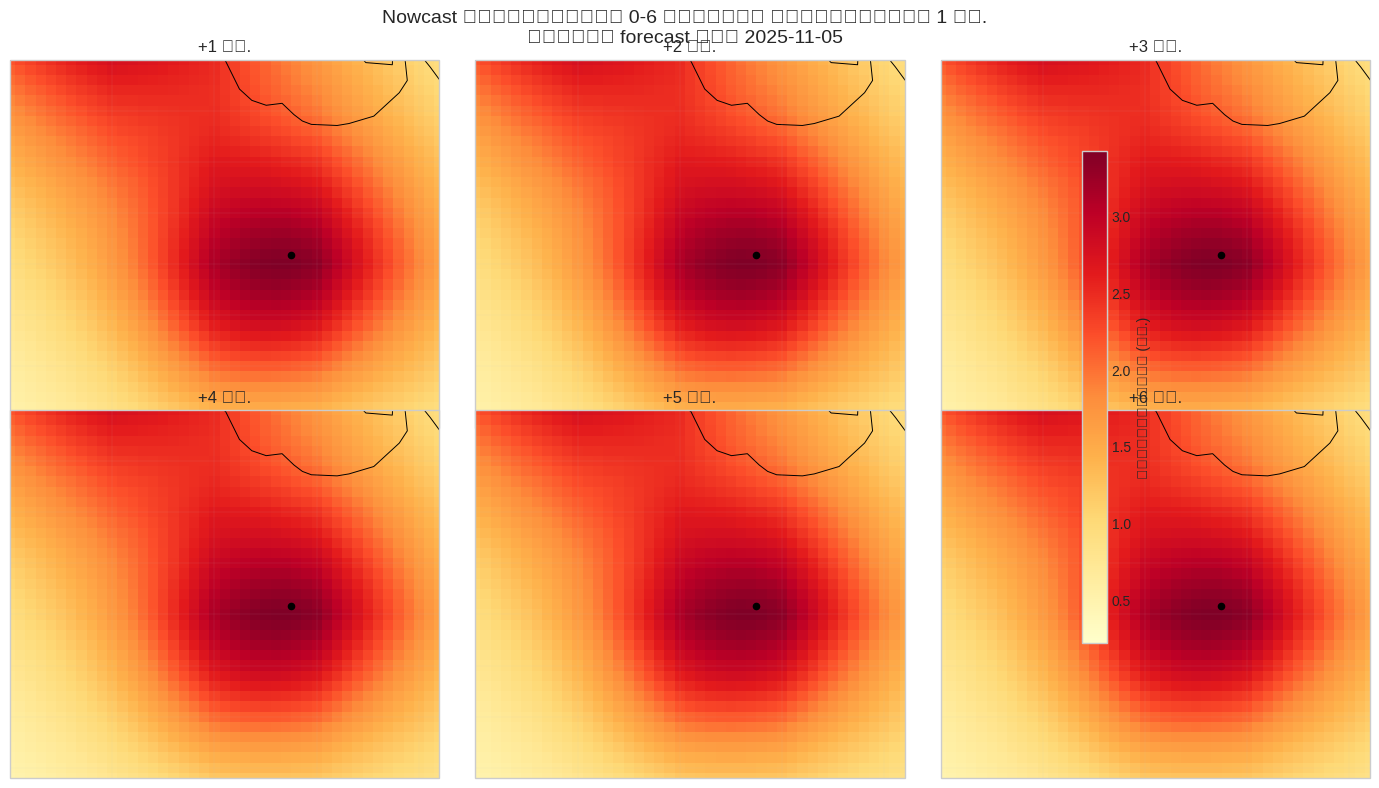

In [13]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for hour_ahead, ax in enumerate(axes.flat, start=1):
    data = hourly_nowcast.sel(hour_ahead=hour_ahead)
    im = ax.pcolormesh(
        hires_ds["lon"],
        hires_ds["lat"],
        data,
        cmap="YlOrRd",
        shading="auto",
        transform=ccrs.PlateCarree(),
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.7)
    ax.gridlines(draw_labels=False, linewidth=0.2, alpha=0.3)
    ax.set_extent([CITY_BBOX["west"], CITY_BBOX["east"], CITY_BBOX["south"], CITY_BBOX["north"]], crs=ccrs.PlateCarree())
    ax.scatter(HATYAI["lon"], HATYAI["lat"], c="black", s=20, transform=ccrs.PlateCarree())
    ax.set_title(f"+{hour_ahead} ชม.")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02, label="ฝนรายชั่วโมง (มม.)")
fig.suptitle(
    f"Nowcast เชิงพื้นที่ 0-6 ชั่วโมง ระดับประมาณ 1 กม.\nออกจาก forecast รอบ {PRIMARY_ISSUE_TIME:%Y-%m-%d}",
    fontsize=14,
)
plt.tight_layout()
plt.show()


## Visualization 3: forecast รอบ 2025-11-05 มองเหตุการณ์ปลายทางอย่างไร


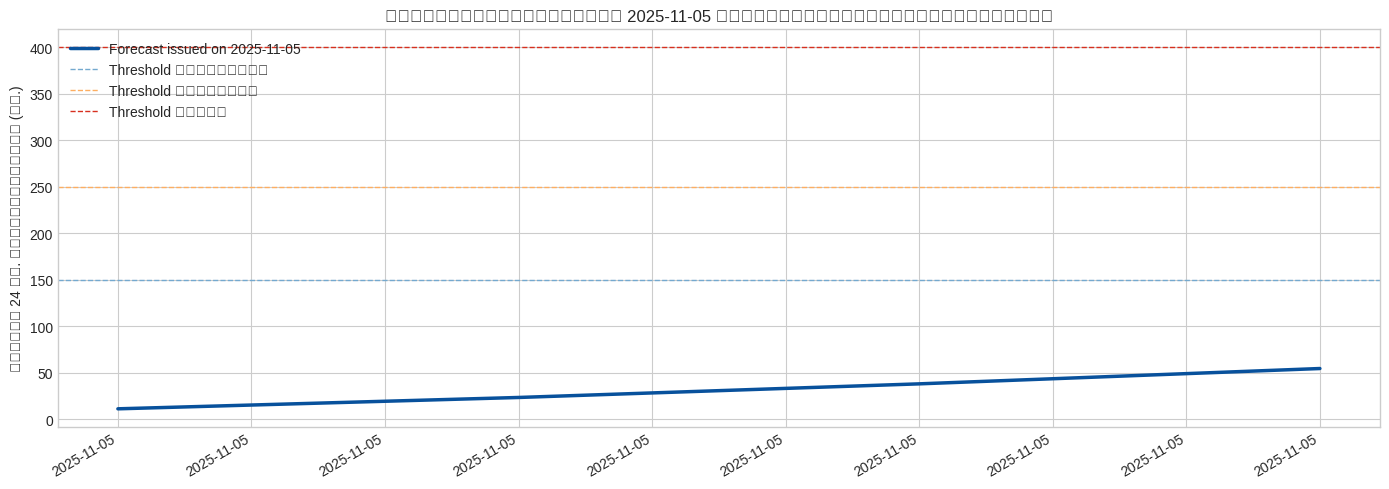

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    primary_operational["valid_time"],
    primary_operational["max_24h_mm"],
    color="#08519c",
    linewidth=2.5,
    label=f"Forecast issued on {PRIMARY_ISSUE_TIME:%Y-%m-%d}",
)
ax.axhline(150, color="#74a9cf", linestyle="--", linewidth=1, label="Threshold เฝ้าระวัง")
ax.axhline(250, color="#fdae61", linestyle="--", linewidth=1, label="Threshold เตือนภัย")
ax.axhline(400, color="#d7301f", linestyle="--", linewidth=1, label="Threshold วิกฤต")

for _, row in primary_operational.iterrows():
    if row["valid_time"].normalize() in set(timeline_df["date"]):
        ax.scatter(
            row["valid_time"],
            row["max_24h_mm"],
            s=80,
            color=LEVEL_COLORS[row["alert_level"]],
            edgecolors="black",
            zorder=3,
        )
        ax.text(
            row["valid_time"],
            row["max_24h_mm"] + 12,
            row["alert_level"],
            fontsize=8,
            ha="center",
        )

ax.set_title(f"ภาพการพยากรณ์จากรอบ {PRIMARY_ISSUE_TIME:%Y-%m-%d} ต่อยอดถึงช่วงน้ำท่วมหาดใหญ่")
ax.set_ylabel("ฝนสะสม 24 ชม. สูงสุดในเมือง (มม.)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=30, ha="right")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## Visualization 4: เส้นเวลาแจ้งเตือนอัตโนมัติ


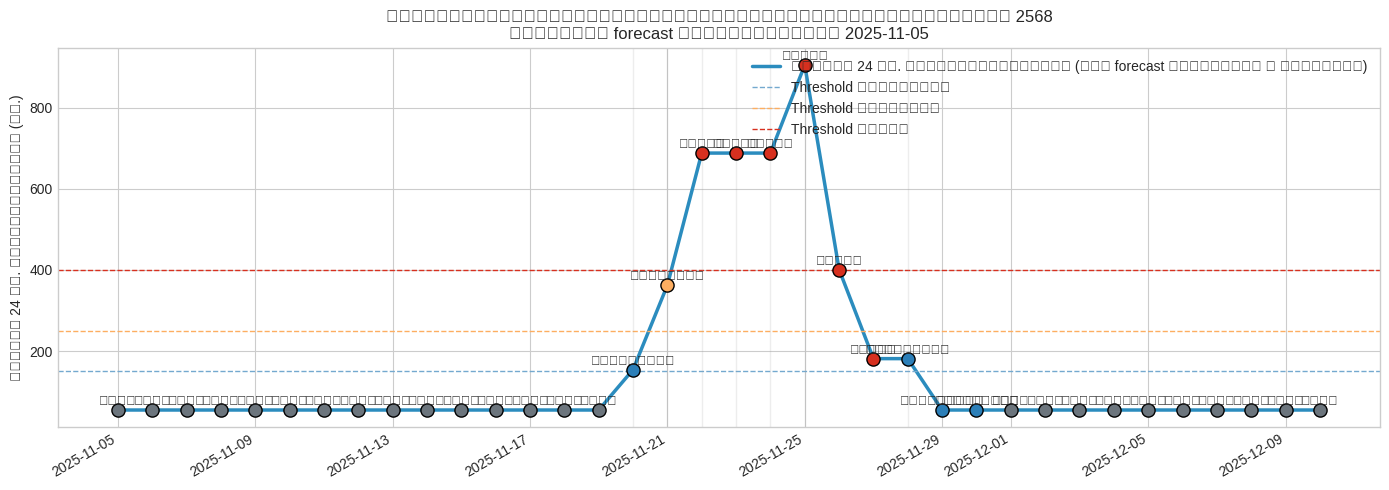

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    daily_alert_df["date"],
    daily_alert_df["max_24h_mm"],
    color="#2b8cbe",
    linewidth=2.5,
    label="ฝนสะสม 24 ชม. สูงสุดในเขตเมือง (ใช้ forecast รอบล่าสุด ณ เวลานั้น)",
)
ax.axhline(150, color="#74a9cf", linestyle="--", linewidth=1, label="Threshold เฝ้าระวัง")
ax.axhline(250, color="#fdae61", linestyle="--", linewidth=1, label="Threshold เตือนภัย")
ax.axhline(400, color="#d7301f", linestyle="--", linewidth=1, label="Threshold วิกฤต")

for _, row in daily_alert_df.iterrows():
    ax.scatter(
        row["date"],
        row["max_24h_mm"],
        s=90,
        color=LEVEL_COLORS[row["alert_level"]],
        edgecolors="black",
        zorder=3,
    )
    ax.text(
        row["date"],
        row["max_24h_mm"] + 12,
        row["alert_level"],
        fontsize=9,
        ha="center",
    )

for _, row in timeline_df.iterrows():
    ax.axvline(row["date"], color="#9e9e9e", alpha=0.18, linewidth=1)

ax.set_title("ระบบเตือนภัยอัตโนมัติสำหรับเหตุการณ์น้ำท่วมหาดใหญ่ 2568\nเริ่มออก forecast รายวันตั้งแต่ 2025-11-05")
ax.set_ylabel("ฝนสะสม 24 ชม. สูงสุดในเมือง (มม.)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.legend(loc="upper right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## สรุปเชิงปฏิบัติการ

จากเดโมนี้ เราได้ pipeline เตือนภัยที่พร้อมต่อยอดดังนี้:

- ระดับหลายวัน: ใช้ Earth2 ประเมินความเสี่ยงล่วงหน้าได้ถึง 15 วัน
- ระดับพื้นที่: crop ลงมาเฉพาะหาดใหญ่และลุ่มน้ำที่เกี่ยวข้อง
- ระดับชั่วโมง: แตกฝน 6 ชั่วโมงแรกเป็น nowcast เชิงพื้นที่ระดับกิโลเมตร
- ระดับการตัดสินใจ: แปลงฝนสะสมเป็น `เฝ้าระวัง`, `เตือนภัย`, `วิกฤต`

แนวทางต่อยอดกับข้อมูลจริง:

- เชื่อมเรดาร์ฝนหรือ satellite precipitation เช่น GPM, GSMaP, CHIRPS
- เติมข้อมูลระดับน้ำ คลอง ระดับน้ำท่า หรือสถานีวัดฝนภาคพื้นดิน
- สร้าง geofencing เป็นรายตำบลหรือรายชุมชน
- ส่งผลออกเป็น dashboard, LINE alert, SMS, หรือระบบ command center

หากต้องการทำเวอร์ชัน production จริง ขั้นต่อไปคือแยก notebook นี้ออกเป็น 4 service:

1. Forecast ingestion service
2. Local downscaling and fusion service
3. Flood-risk scoring service
4. Alert delivery service
